In [88]:
import numpy as np
import matplotlib.pyplot as plt
rng=np.random.default_rng()

We want to be able to simulate stock returns modeled by a Brownian motion together with a compound Poisson process. Given an interval of time $[0,t]$ the price $S(t)$ of the stock at time $t$ is the random variable
$$S(t)=S(0)\text{exp}\biggl\{\sigma W(t) + \left( \alpha - \beta\lambda -\frac{1}{2}\sigma^2\right) t \biggr\} \prod_{i=1}^{N(t)}(Y_i+1).$$
This process is a product of two random variables, the first is a continuous stochastic process
$$X(t)=S(0)\text{exp}\biggl\{\sigma W(t) + \left( \alpha - \beta\lambda -\frac{1}{2}\sigma^2\right) t \biggr\}$$
where $W(t)$ is a Brownian motion. The second random variable is a pure jump process
$$J(t)=\prod_{i=1}^{N(t)}(Y_i+1).$$
To compute the log returns $\log(S(t))$ we need to compute both $\log(X(t))$ and $\log(J(t))$. 

To simulate $J(t)$ we need to compute the $Y_i$. The sum of the $Y_i$ is a compound poisson process
$$Q(t)=\sum_{i=1}^m Y_i$$
We can also write $Q(t)$ in the form
$$Q(t)=\sum_{i=1}^m y_iN_i(t)$$
where $-1<y_1<\dots<y_m$ are integers, and the $N_i(t)$ are Poisson processes of intensity $\lambda_i$. The sum of the $N_i(t)$
$$N(t)=\sum_{i=1}^m N_i(t)$$
is a Poisson process with intensity $\lambda=\sum\lambda_i$.
So we need a function that takes in some data and returns an array log_returns of the values $log(J(t))$. Our function will take the following variables

Lamb= an array of length $m$ of the intensities $\lambda_i$ of the Poisson processes $N_i(t)$.

Y = an array of the integers $y_i$ which determines the direction and magnitude of the jump for Poisson process $N_i(t)$

n_steps = the number of measurements of the stock price per year, the size of the array log_returns

In [126]:
def pure_jump(lamb,Y,probabilities,n_steps):
    p_process=np.random.poisson(lamb,n_steps)
    returns=0
    log_returns=np.array([np.sum(np.log(rng.choice(Y,size=step,p=probabilities)+1)) for step in p_process])
    return log_returns
        

In [136]:
Y=[-0.05,0.05]
lamb=1
probabilities=[1/2,1/2]
n_steps=252
x=pure_jump(lamb,Y,probabilities,n_steps)

In [137]:
y=np.cumsum(x)
print(np.size(y))
z=np.linspace(1,n_steps+1,n_steps)
print(np.size(z))

252
252


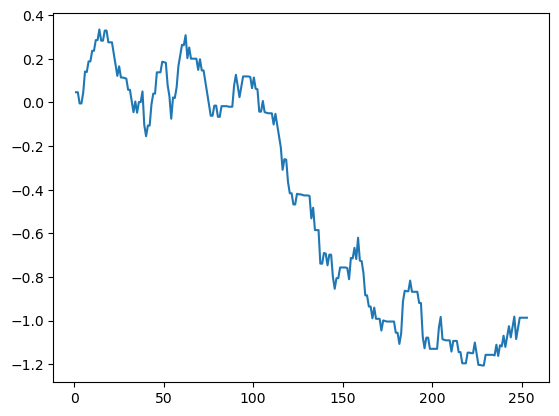

In [138]:
plt.plot(z,y)
plt.show()